![Stock Price Prediction](https://drive.google.com/file/d/18pjV-PKzs7RgYPKxKaEjVTAJgbYg47PM/view?usp=sharing)



# Import Libraries

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import plotly.express as px

# models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# Importing data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/kaiserahmedsiyam/stock-price/dse_clean_master_dataset_2026.csv')

In [3]:
df.head()

,DATE,STOCK,OPEN_PRICE,HIGH_PRICE,LOW_PRICE,CLOSE_PRICE,VOLUME,RETURN,VOLATILITY_7D,PRICE_CHANGE,MA_7,MA_30,TREND,MOMENTUM
0,2026-01-01,00DS30,1853.53914,1872.46000,1854.83417,1869.42403,3681599000,NaN,NaN,15.88489,NaN,NaN,False,NaN
1,2026-01-01,00DSES,1000.71510,1009.86932,1001.34793,1006.00444,3681599000,NaN,NaN,5.28934,NaN,NaN,False,NaN
2,2026-01-01,00DSEX,4865.33685,4916.03253,4869.60121,4910.61355,3681599000,NaN,NaN,45.27670,NaN,NaN,False,NaN
3,2026-01-01,00DSMEX,855.92825,884.69478,856.30390,876.61131,32508000,NaN,NaN,20.68306,NaN,NaN,False,NaN
4,2026-01-01,1JANATAMF,2.60000,2.60000,2.50000,2.50000,506291,NaN,NaN,-0.10000,NaN,NaN,False,NaN


In [4]:
df.columns

Index(['DATE', 'STOCK', 'OPEN_PRICE', 'HIGH_PRICE', 'LOW_PRICE', 'CLOSE_PRICE',
       'VOLUME', 'RETURN', 'VOLATILITY_7D', 'PRICE_CHANGE', 'MA_7', 'MA_30',
       'TREND', 'MOMENTUM'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25609 entries, 0 to 25608
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   DATE           25609 non-null  object 
 1   STOCK          25609 non-null  object 
 2   OPEN_PRICE     25609 non-null  float64
 3   HIGH_PRICE     25609 non-null  float64
 4   LOW_PRICE      25609 non-null  float64
 5   CLOSE_PRICE    25609 non-null  float64
 6   VOLUME         25609 non-null  int64  
 7   RETURN         25159 non-null  float64
 8   VOLATILITY_7D  22584 non-null  float64
 9   PRICE_CHANGE   25609 non-null  float64
 10  MA_7           23006 non-null  float64
 11  MA_30          13495 non-null  float64
 12  TREND          25609 non-null  bool   
 13  MOMENTUM       23428 non-null  float64
dtypes: bool(1), float64(10), int64(1), object(2)
memory usage: 2.6+ MB


In [6]:
df.isnull().sum()

DATE                 0
STOCK                0
OPEN_PRICE           0
HIGH_PRICE           0
LOW_PRICE            0
CLOSE_PRICE          0
VOLUME               0
RETURN             450
VOLATILITY_7D     3025
PRICE_CHANGE         0
MA_7              2603
MA_30            12114
TREND                0
MOMENTUM          2181
dtype: int64

In [7]:
df['STOCK'].count()

np.int64(25609)

In [8]:
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')

In [9]:
df['Target'] = df['CLOSE_PRICE'].shift(-1)  # Next day close
df = df.dropna(subset=['Target'])

In [10]:
df

,DATE,STOCK,OPEN_PRICE,HIGH_PRICE,LOW_PRICE,CLOSE_PRICE,VOLUME,RETURN,VOLATILITY_7D,PRICE_CHANGE,MA_7,MA_30,TREND,MOMENTUM,Target
0,2026-01-01,00DS30,1853.53914,1872.46,1854.83417,1869.42403,3681599000,NaN,NaN,15.88489,NaN,NaN,False,NaN,169.2
282,2026-01-01,PADMAOIL,169.50000,169.50,167.60000,169.20000,53074,NaN,NaN,-0.30000,NaN,NaN,False,NaN,16.7
281,2026-01-01,PADMALIFE,16.70000,16.80,16.50000,16.70000,30618,NaN,NaN,0.00000,NaN,NaN,False,NaN,8.6
280,2026-01-01,ORYZAAGRO,8.60000,8.90,8.60000,8.60000,269775,NaN,NaN,0.00000,NaN,NaN,False,NaN,27.8
279,2026-01-01,ORIONPHARM,27.20000,28.50,27.20000,27.80000,57904,NaN,NaN,0.60000,NaN,NaN,False,NaN,357.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25329,2026-04-09,ESQUIRENIT,20.30000,20.50,19.80000,20.00000,74609,-0.009901,0.018861,-0.30000,20.100000,20.296667,False,-0.004765,16.2
25328,2026-04-09,EPGL,16.50000,16.60,16.20000,16.20000,374034,-0.024096,0.029195,-0.30000,16.428571,16.646667,False,-0.006842,48.9
25327,2026-04-09,ENVOYTEX,49.60000,49.60,48.70000,48.90000,110950,-0.016097,0.020279,-0.70000,48.971429,49.936667,False,-0.002236,15.3
25326,2026-04-09,EMERALDOIL,15.50000,15.80,15.20000,15.30000,111588,-0.012903,0.025337,-0.20000,15.457143,16.003333,False,-0.007324,2.3


# Data preprocessing

In [11]:
# Handle nulls  Time series friendly

df = df.ffill()  
df = df.bfill()  
df = df.fillna(df.select_dtypes(include='number').mean())


# Or use Imputer 
# imputer = SimpleImputer(strategy='mean')  # or 'median'
# numeric_cols = df.select_dtypes(include=[np.number]).columns
# df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# print("Nulls after cleaning:", df.isnull().sum().sum())

# EDA

In [12]:
fig = px.histogram(df, 
                   x='Target', 
                   marginal='box', 
                   nbins=47,
                   color='STOCK', 
                   # color_discrete_sequence=['red', 'blue'], 
                   title='Distribution of target')
fig.update_layout(bargap=0.1)
fig.show(renderer='iframe')

In [13]:
fig = px.histogram(df, 
                   x='Target',  
                   nbins=47, 
                   title='Distribution of target')
fig.update_layout(bargap=0.1)
fig.show(renderer='iframe')

Text(0.5, 1.0, 'Pairplot')

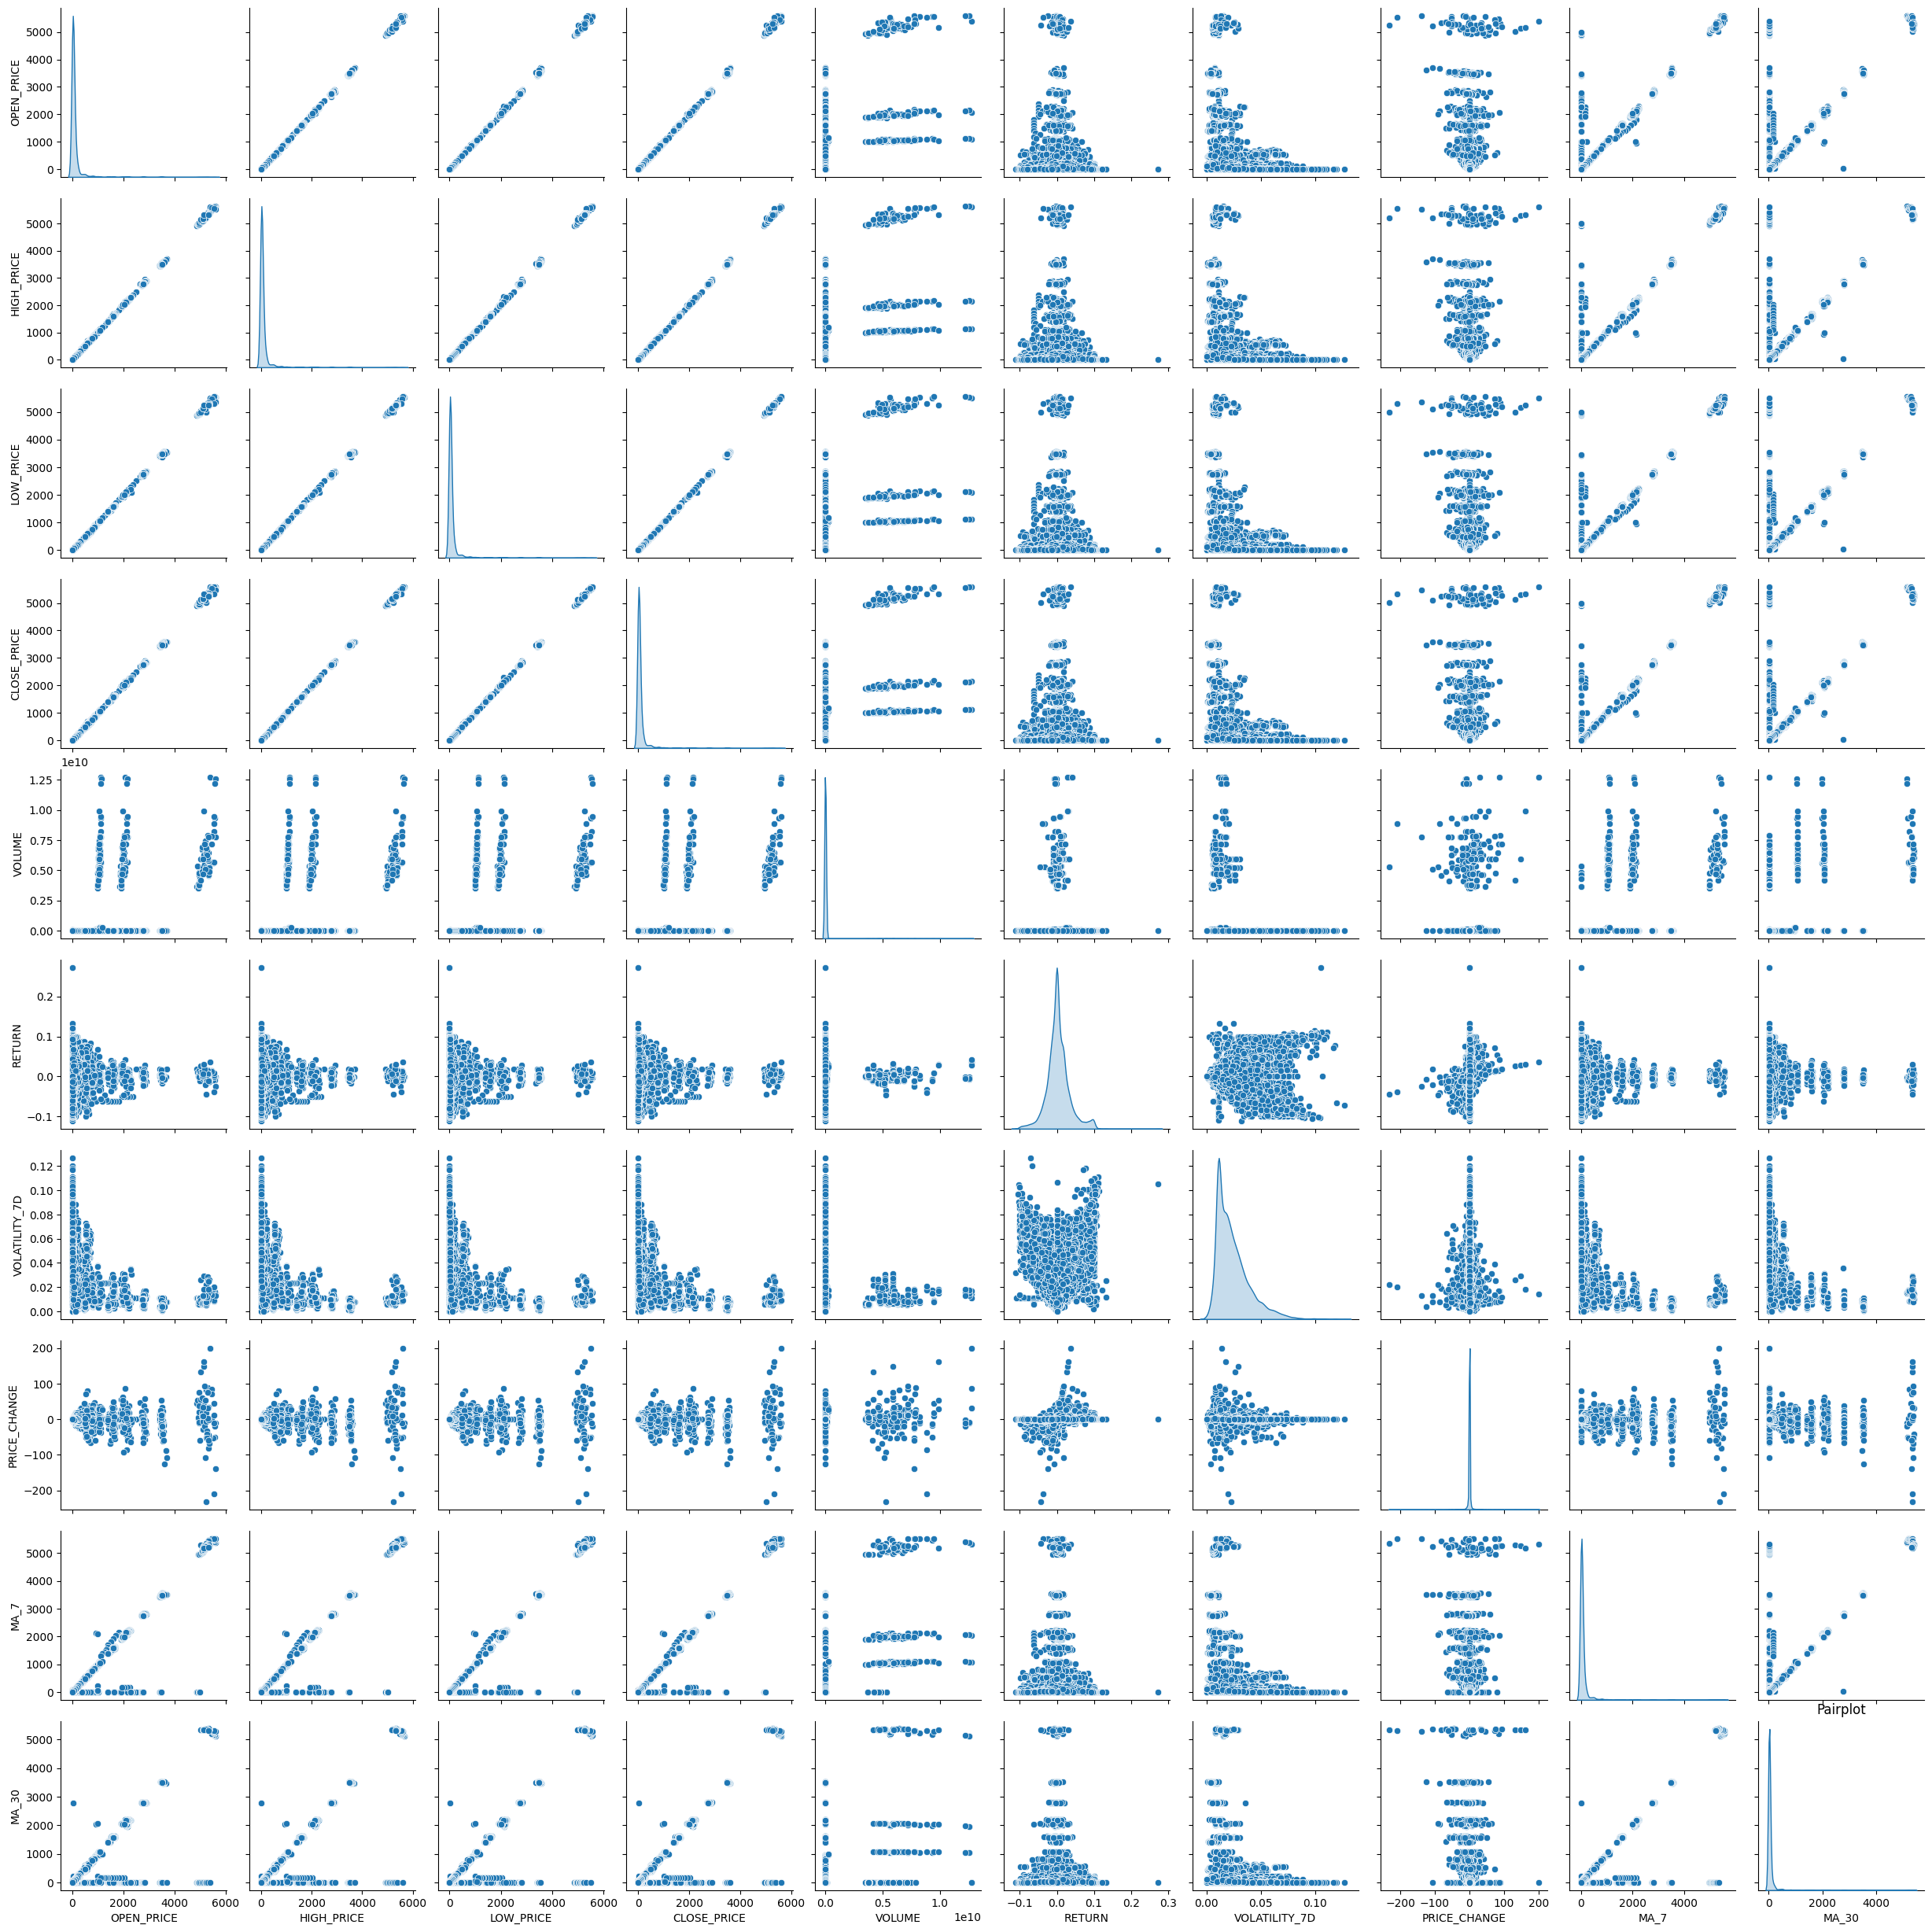

In [14]:
sns.pairplot(df[['OPEN_PRICE', 'HIGH_PRICE', 'LOW_PRICE', 'CLOSE_PRICE',
       'VOLUME', 'RETURN', 'VOLATILITY_7D', 'PRICE_CHANGE', 'MA_7', 'MA_30',]], kind='scatter', diag_kind='kde')
plt.title("Pairplot")

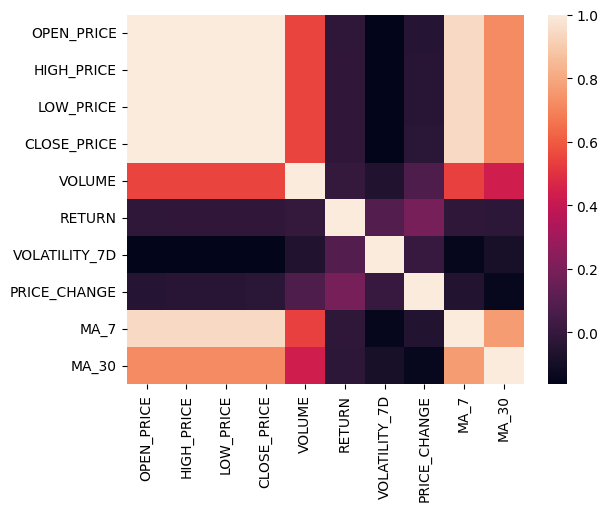

In [15]:
corr = df[['OPEN_PRICE', 'HIGH_PRICE', 'LOW_PRICE', 'CLOSE_PRICE',
       'VOLUME', 'RETURN', 'VOLATILITY_7D', 'PRICE_CHANGE', 'MA_7', 'MA_30']].corr()
heatmap = sns.heatmap(corr)

# Feature Selection

In [16]:
df.columns

Index(['DATE', 'STOCK', 'OPEN_PRICE', 'HIGH_PRICE', 'LOW_PRICE', 'CLOSE_PRICE',
       'VOLUME', 'RETURN', 'VOLATILITY_7D', 'PRICE_CHANGE', 'MA_7', 'MA_30',
       'TREND', 'MOMENTUM', 'Target'],
      dtype='object')

In [17]:
# Lag features (previous days)
for lag in [1, 2, 3,4, 5]:
    df[f'Close_lag_{lag}'] = df['CLOSE_PRICE'].shift(lag)

df = df.dropna()

In [18]:
df.columns

Index(['DATE', 'STOCK', 'OPEN_PRICE', 'HIGH_PRICE', 'LOW_PRICE', 'CLOSE_PRICE',
       'VOLUME', 'RETURN', 'VOLATILITY_7D', 'PRICE_CHANGE', 'MA_7', 'MA_30',
       'TREND', 'MOMENTUM', 'Target', 'Close_lag_1', 'Close_lag_2',
       'Close_lag_3', 'Close_lag_4', 'Close_lag_5'],
      dtype='object')

<Axes: ylabel='Target'>

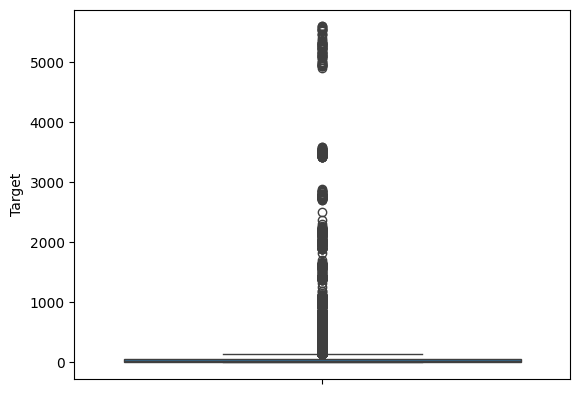

In [19]:
sns.boxplot(df['Target'])

# Introduce X & Y


In [20]:
features = [ 'OPEN_PRICE', 'HIGH_PRICE', 'LOW_PRICE', 'CLOSE_PRICE',
            'VOLUME', 'RETURN', 'VOLATILITY_7D', 'PRICE_CHANGE', 'MA_7', 'MA_30',
            'MOMENTUM'] + [col for col in df.columns if 'lag' in col]
X = df[features]
y = df['Target']  # Or df['Close'] for same-day prediction



In [21]:
X

,OPEN_PRICE,HIGH_PRICE,LOW_PRICE,CLOSE_PRICE,VOLUME,RETURN,VOLATILITY_7D,PRICE_CHANGE,MA_7,MA_30,MOMENTUM,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_4,Close_lag_5
278,340.1,357.8,340.1,357.1,455721,0.018182,0.011057,17.0,2.000000,12.800000,0.000557,27.8,8.6,16.7,169.2,1869.42403
277,7.0,7.1,6.9,7.0,411082,0.018182,0.011057,0.0,2.000000,12.800000,0.000557,357.1,27.8,8.6,16.7,169.20000
276,137.6,137.6,137.2,137.3,5801,0.018182,0.011057,-0.3,2.000000,12.800000,0.000557,7.0,357.1,27.8,8.6,16.70000
275,15.3,15.9,15.3,15.5,185883,0.018182,0.011057,0.2,2.000000,12.800000,0.000557,137.3,7.0,357.1,27.8,8.60000
274,5.7,5.7,5.5,5.5,51984,0.018182,0.011057,-0.2,2.000000,12.800000,0.000557,15.5,137.3,7.0,357.1,27.80000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25329,20.3,20.5,19.8,20.0,74609,-0.009901,0.018861,-0.3,20.100000,20.296667,-0.004765,9.5,3.7,3.3,16.0,2.30000
25328,16.5,16.6,16.2,16.2,374034,-0.024096,0.029195,-0.3,16.428571,16.646667,-0.006842,20.0,9.5,3.7,3.3,16.00000
25327,49.6,49.6,48.7,48.9,110950,-0.016097,0.020279,-0.7,48.971429,49.936667,-0.002236,16.2,20.0,9.5,3.7,3.30000
25326,15.5,15.8,15.2,15.3,111588,-0.012903,0.025337,-0.2,15.457143,16.003333,-0.007324,48.9,16.2,20.0,9.5,3.70000


In [22]:
#
# features = [ 'OPEN_PRICE', 'HIGH_PRICE', 'LOW_PRICE', 'CLOSE_PRICE',
#             'VOLUME', 'RETURN', 'VOLATILITY_7D', 'PRICE_CHANGE', 'MA_7', 'MA_30',
#             'MOMENTUM']
# X = df[features]
# y = df['Target']

# Split the dataset

In [23]:
# Time-based split (80% train, 20% test)

split_idx = int(len(df) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

## Feature Selection

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel

selector_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

selector_model.fit(X_train, y_train)

selector = SelectFromModel(
    selector_model,
    threshold="median"
)

selector.fit(X_train, y_train)

selected_features = X_train.columns[
    selector.get_support()
]

print("Selected Features:")
print(selected_features)

X_train = selector.transform(X_train)
X_test = selector.transform(X_test)

Selected Features:
Index(['OPEN_PRICE', 'LOW_PRICE', 'VOLUME', 'Close_lag_1', 'Close_lag_2',
       'Close_lag_3', 'Close_lag_4', 'Close_lag_5'],
      dtype='object')


## Scaling

In [25]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)


##### If we still want random split (not recommended for stocks):
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Model Training & Evaluation

In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, min_samples_split=3, min_samples_leaf=1,random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_split=2, min_samples_leaf=1,random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(learning_rate=0.001, n_estimators=100,random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=50, random_state=42),
    "SVR": SVR(epsilon= 0.01, kernel='rbf'),
    "KNN": KNeighborsRegressor(n_neighbors=10, leaf_size=10,),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    
}

## Evaluation

In [27]:
from sklearn.metrics import mean_absolute_percentage_error

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "MAPE":round(mape, 4),
        "R²": round(r2, 4)
        
    })
    
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.4f} R²={r2:.4f}")

# Display results as DataFrame
results_df = pd.DataFrame(results)
print(results_df.sort_values("RMSE"))

Linear Regression: MAE=139.78, RMSE=395.62, MAPE=6.7894 R²=0.0354
Ridge: MAE=139.78, RMSE=395.72, MAPE=6.7890 R²=0.0349
Lasso: MAE=139.78, RMSE=395.92, MAPE=6.7881 R²=0.0339
Decision Tree: MAE=371.56, RMSE=922.24, MAPE=26.8056 R²=-4.2418
Random Forest: MAE=149.21, RMSE=298.53, MAPE=9.9108 R²=0.4507
Gradient Boosting: MAE=140.56, RMSE=385.83, MAPE=6.9677 R²=0.0825
AdaBoost: MAE=598.05, RMSE=643.28, MAPE=46.5800 R²=-1.5503
SVR: MAE=101.93, RMSE=412.44, MAPE=1.3027 R²=-0.0484
KNN: MAE=59.45, RMSE=227.88, MAPE=3.6936 R²=0.6800
XGBoost: MAE=116.69, RMSE=269.97, MAPE=6.1837 R²=0.5508
LightGBM: MAE=93.01, RMSE=263.17, MAPE=3.9568 R²=0.5731
                Model       MAE      RMSE     MAPE      R²
8                 KNN   59.4500  227.8826   3.6936  0.6800
10           LightGBM   93.0098  263.1735   3.9568  0.5731
9             XGBoost  116.6880  269.9675   6.1837  0.5508
4       Random Forest  149.2109  298.5338   9.9108  0.4507
5   Gradient Boosting  140.5614  385.8309   6.9677  0.0825
0   L

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



In [28]:
print(results_df.sort_values("MAPE"))

                Model       MAE      RMSE     MAPE      R²
7                 SVR  101.9268  412.4447   1.3027 -0.0484
8                 KNN   59.4500  227.8826   3.6936  0.6800
10           LightGBM   93.0098  263.1735   3.9568  0.5731
9             XGBoost  116.6880  269.9675   6.1837  0.5508
2               Lasso  139.7791  395.9157   6.7881  0.0339
1               Ridge  139.7810  395.7230   6.7890  0.0349
0   Linear Regression  139.7832  395.6241   6.7894  0.0354
5   Gradient Boosting  140.5614  385.8309   6.9677  0.0825
4       Random Forest  149.2109  298.5338   9.9108  0.4507
3       Decision Tree  371.5578  922.2412  26.8056 -4.2418
6            AdaBoost  598.0528  643.2764  46.5800 -1.5503


# pick a best model

/tmp/ipykernel_57/2889273067.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 1.0, 'Accuracy Score Analysis ')

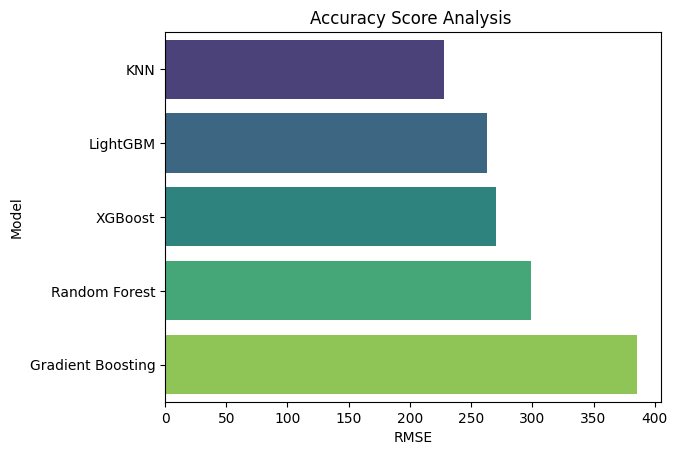

In [29]:
results_df_rmse=results_df.nsmallest(columns='RMSE',n=5)
sns.barplot(data=results_df_rmse,y="Model",x='RMSE',palette="viridis")
plt.title("Accuracy Score Analysis ")

In [30]:
results_df_rmse

,Model,MAE,RMSE,MAPE,R²
8,KNN,59.4500,227.8826,3.6936,0.6800
10,LightGBM,93.0098,263.1735,3.9568,0.5731
9,XGBoost,116.6880,269.9675,6.1837,0.5508
4,Random Forest,149.2109,298.5338,9.9108,0.4507
5,Gradient Boosting,140.5614,385.8309,6.9677,0.0825


/tmp/ipykernel_57/2375906500.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 1.0, 'Accuracy Score Analysis (Mean Absolute Percentage Error) ')

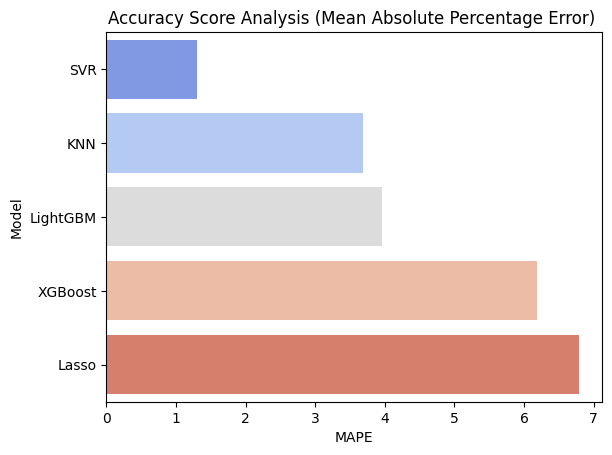

In [31]:
results_df_mape=results_df.nsmallest(columns='MAPE',n=5)
sns.barplot(data=results_df_mape,y="Model",x='MAPE',palette="coolwarm")
plt.title("Accuracy Score Analysis (Mean Absolute Percentage Error) ")

In [32]:
results_df_mape

,Model,MAE,RMSE,MAPE,R²
7,SVR,101.9268,412.4447,1.3027,-0.0484
8,KNN,59.4500,227.8826,3.6936,0.6800
10,LightGBM,93.0098,263.1735,3.9568,0.5731
9,XGBoost,116.6880,269.9675,6.1837,0.5508
2,Lasso,139.7791,395.9157,6.7881,0.0339


# Hyperperameter Tunning

In [33]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor

params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'algorithm': ['ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [10, 15, 20, 30, 45, 65],
    'p': [1, 2],  # 1 = manhattan, 2 = euclidean (only used when metric='minkowski')
    'metric': ['minkowski']
}

model = KNeighborsRegressor()

random_search = RandomizedSearchCV(
    model,
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=2,
    random_state=42  # for reproducibility
)

random_search.fit(X_train, y_train)

best_parameters = random_search.best_params_
best_model = random_search.best_estimator_

print(best_parameters)

{'weights': 'distance', 'p': 1, 'n_neighbors': 5, 'metric': 'minkowski', 'leaf_size': 15, 'algorithm': 'kd_tree'}


In [34]:
knn_hyp_para = best_parameters
knn_hyp = best_model

print("knn_hyp_para")
print("knn_hyp")

knn_hyp_para
knn_hyp


In [35]:
y_pred = knn_hyp.predict(X_test)

In [36]:
mae_hy = mean_absolute_error(y_test, y_pred)

rmse_hy = np.sqrt(mean_squared_error(y_test, y_pred))
mape_hy = mean_absolute_percentage_error(y_test, y_pred)

r2_hy = r2_score(y_test, y_pred)

print("MAE:", mae_hy)
print("RMSE:", rmse_hy)
print("R²:", r2_hy)
print("MAPE:", mape_hy)

MAE: 50.023456087784425
RMSE: 218.0172005739635
R²: 0.7070614353090497
MAPE: 2.658060877652988


In [37]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.neighbors import KNeighborsRegressor

# params = {
#     'n_neighbors': [10,15,18,20,30,40],
#     'weights': ['uniform', 'distance'],
#     'algorithm': ['ball_tree', 'kd_tree', 'brute'],
#     'leaf_size': [8,15,21,30,40],
#     'p': [1, 2],  # 1 = manhattan, 2 = euclidean (only used when metric='minkowski')
#     'metric': ['minkowski']
# }

# model = KNeighborsRegressor()

# random_search = RandomizedSearchCV(
#     model,
#     param_distributions=params,
#     n_iter=50,
#     cv=5,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=2,
#     random_state=43  # for reproducibility
# )

# random_search.fit(X_train, y_train)

# best_parameters_2 = random_search.best_params_
# best_model_2 = random_search.best_estimator_

# print(best_parameters_2)

{'weights': 'distance', 'p': 1, 'n_neighbors': 10, 'metric': 'minkowski', 'leaf_size': 15, 'algorithm': 'brute'}


In [38]:
# best_parameters_2
# best_model_2

KNeighborsRegressor(algorithm='brute', leaf_size=15, n_neighbors=10, p=1,
                    weights='distance')

In [39]:
# y_pred_2 = best_model_2.predict(X_test)

In [40]:
# mae_hy_2 = mean_absolute_error(y_test, y_pred_2)

# rmse_hy_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))
# mape_hy_2 = mean_absolute_percentage_error(y_test, y_pred_2)

# r2_hy_2 = r2_score(y_test, y_pred_2)

# print("MAE_2:", mae_hy_2)
# print("RMSE_2:", rmse_hy_2)
# print("R²_2:", r2_hy_2)
# print("MAPE_2:", mape_hy_2)

MAE_2: 54.356529630773956
RMSE_2: 223.4177136617623
R²_2: 0.6923689002998937
MAPE_2: 3.21493438773403


In [41]:
new_row =pd.DataFrame ([{
    'Model': 'knn_hyp',
    'MAE': mae_hy,
    'RMSE': rmse_hy,
    'R²':  r2_hy,
    "MAPE": mape_hy
}])
results_df_hyp = pd.concat([results_df_mape, new_row], ignore_index=True)

In [42]:
results_df_hyp

,Model,MAE,RMSE,MAPE,R²
0,SVR,101.926800,412.444700,1.302700,-0.048400
1,KNN,59.450000,227.882600,3.693600,0.680000
2,LightGBM,93.009800,263.173500,3.956800,0.573100
3,XGBoost,116.688000,269.967500,6.183700,0.550800
4,Lasso,139.779100,395.915700,6.788100,0.033900
5,knn_hyp,50.023456,218.017201,2.658061,0.707061


/tmp/ipykernel_57/455815983.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 1.0, 'Accuracy Score Analysis ')

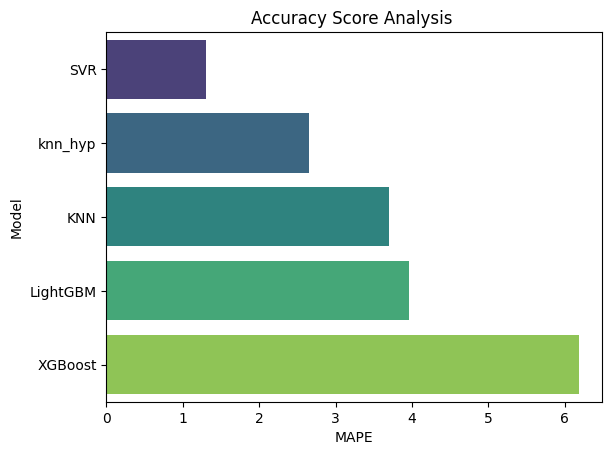

In [43]:
results_df_hyp=results_df_hyp.nsmallest(columns='MAPE',n=5)
sns.barplot(data=results_df_hyp,y="Model",x='MAPE', palette="viridis")
plt.title("Accuracy Score Analysis ")

In [45]:
import pickle

pickle.dump(
    selector,
    open(
        "feature_selector.pkl",
        "wb"
    )
)

pickle.dump(
    scaler,
    open(
        "scaler.pkl",
        "wb"
    )
)

pickle.dump(
    model,
    open(
        "knn_hyp.pkl",
        "wb"
    )
)

print("\nSaved Successfully")


Saved Successfully


In [49]:
import pickle
import pandas as pd

# ============================
# 1. Load the saved objects
# ============================
with open("feature_selector.pkl", "rb") as f:
    selector = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("knn_hyp.pkl", "rb") as f:
    model = pickle.load(f)

print("Loaded Successfully")



Loaded Successfully


In [50]:
# ============================
# 2. Load your new data
# ============================
new_data = pd.read_csv('/kaggle/input/datasets/kaiserahmedsiyam/stock-price/dse_clean_master_dataset_2026.csv')   # replace with your actual file/source

def preprocess(new_data):
    # df = df.sort_values('DATE')  # ensure chronological order
    
    new_data['Target'] = new_data['CLOSE_PRICE'].shift(-1)  # Next day close
    new_data = new_data.dropna(subset=['Target']).copy()
    
    for lag in [1, 2, 3, 4, 5]:
        new_data[f'Close_lag_{lag}'] = new_data['CLOSE_PRICE'].shift(lag)
    new_data = new_data.dropna()
    new_data = new_data.drop(columns=['DATE', 'STOCK', 'TREND'], errors='ignore')
    return new_data

# New/inference data — same function, same logic
X_new = preprocess(new_data)
X_new
# If your new data includes the target column, separate it out
# (only needed if you want to evaluate performance, not just predict)
if 'Target' in X_new.columns:
    y_new = X_new['Target']
    X_new = X_new.drop(columns=['Target'])
    
else:
    X_new = new_data
    y_new = None



In [51]:
X_new.columns

Index(['OPEN_PRICE', 'HIGH_PRICE', 'LOW_PRICE', 'CLOSE_PRICE', 'VOLUME',
       'RETURN', 'VOLATILITY_7D', 'PRICE_CHANGE', 'MA_7', 'MA_30', 'MOMENTUM',
       'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_4',
       'Close_lag_5'],
      dtype='object')

In [52]:
y_new


11979    1118.73843
11980    5589.55953
11981     972.79609
11982       3.00000
11983      20.00000
            ...    
25602      26.10000
25603      16.40000
25604    2216.00000
25606       6.90000
25607     129.40000
Name: Target, Length: 13494, dtype: float64

In [59]:
# ============================
# 3. Apply the SAME preprocessing pipeline
# ============================
X_selected = selector.transform(X_new)
X_scaled = scaler.transform(X_selected)

split_idx = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y_new[:split_idx], y_new[split_idx:]
# ============================
# 4. Predict
# ============================
model = model.fit(X_train,y_train)
predictions = model.predict(X_test)
print(predictions)

       OPEN_PRICE  HIGH_PRICE   LOW_PRICE  CLOSE_PRICE       VOLUME    RETURN  \
11979  2145.13236  2162.64987  2118.82970   2135.76198  12570388000 -0.004368   
11980  1127.36816  1136.39861  1116.07773   1118.73843  12570388000 -0.007655   
11981  5600.65736  5653.93240  5549.78655   5589.55953  12570388000 -0.001982   
11982   985.71875  1007.35400   972.79609    972.79609     89493000 -0.013110   
11983     3.00000     3.10000     2.90000      3.00000      3720891  0.034483   

       VOLATILITY_7D  PRICE_CHANGE         MA_7        MA_30  MOMENTUM  \
11979       0.017569      -9.37038  2056.193881  1964.910544  0.013168   
11980       0.012995      -8.62973  1089.826133  1034.108060  0.008640   
11981       0.015146     -11.09783  5376.033884  5122.193736  0.013318   
11982       0.011072     -12.92266   958.815749   945.889463  0.007201   
11983       0.041385       0.00000     2.742857     2.483333  0.021996   

       Close_lag_1  Close_lag_2  Close_lag_3  Close_lag_4  Close_lag

In [60]:
mae_lm = mean_absolute_error(y_test, predictions)
rmse_lm = np.sqrt(mean_squared_error(y_test, predictions))
mape_lm =mean_absolute_percentage_error(y_test, predictions)
r2_lm = r2_score(y_test, predictions)

print("MAE:", mae_lm)
print("RMSE:", rmse_lm)
print("MAPE:", mape_lm)
print("R²:", r2_lm)


MAE: 10.467439616895147
RMSE: 85.01236805201357
MAPE: 0.46081053965071894
R²: 0.9533058780488229


1. build a logic  for take input data and if missing that can be handled by the model own
2. 
    